## Temporal Analysis of butterfly species using cosine similarity
### How does mean cosine distance in a species change over time?

#### Imports and setup

In [46]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

logger.info("Loading libraries...")
import duckdb
import lancedb
import numpy as np
import polars as pl
import os
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


NOTEBOOK_ROOT = Path.cwd()
REPO_ROOT = NOTEBOOK_ROOT if (NOTEBOOK_ROOT / "backend").exists() else NOTEBOOK_ROOT.parent
ENV_PATH = REPO_ROOT / "backend" / ".env"
if not ENV_PATH.exists():
    raise FileNotFoundError(f"Backend environment file not found: {ENV_PATH}")
load_dotenv(ENV_PATH)


def env_path(name):
    value = os.getenv(name)
    if not value:
        raise ValueError(f"Missing {name} in {ENV_PATH}")
    path = Path(value).expanduser()
    return path if path.is_absolute() else (ENV_PATH.parent / path).resolve()


DUCK_DIR = env_path("DUCK_DIR")
LANCE_DIR = env_path("LANCE_DIR")
IMAGE_DIR = env_path("IMAGE_DIR")
GBIF_DIR = env_path("GBIF_DIR")
IMAGE_META_DIR = env_path("IMAGE_META_DIR")

DUCK_PATH = DUCK_DIR / "biocosmos.duckdb"
LANCE_PATH = LANCE_DIR / "biocosmos.lance"
LANCE_TABLE = "nymphalidae"
META_TABLE = "image_meta"
GBIF_TABLE = "gbif_meta"
MIN_SPECIES_IMAGES = 100
TOP_K = 800
LIMIT = 10
SIDES = ["dorsal", "ventral"]
SIDE_COLORS = {
    "dorsal": "royalblue",
    "ventral": "darkorange",
}
BUCKET_YEARS = 10
MIN_BUCKET_IMAGES = 5

logger.info("Python interpreter: %s", os.sys.executable)
logger.info("Loaded paths from %s", ENV_PATH)

2026-09-21 19:58:26,343 [INFO] Loading libraries...
2026-09-21 19:58:26,346 [INFO] Python interpreter: /Users/kiraluna/Projects/bioVisionLab-Project/v1/BioCosmos/.venv/bin/python
2026-09-21 19:58:26,347 [INFO] Loaded paths from /Users/kiraluna/Projects/bioVisionLab-Project/v1/BioCosmos/backend/.env


#### Validate paths

In [47]:
if not LANCE_PATH.exists():
    raise FileNotFoundError(f"LanceDB database not found: {LANCE_PATH}")
if not DUCK_PATH.exists():
    raise FileNotFoundError(f"DuckDB file not found: {DUCK_PATH}")

logger.info("Using DuckDB file: %s", DUCK_PATH)
logger.info("Using LanceDB database: %s", LANCE_PATH)
logger.info("Using image directory: %s%s", IMAGE_DIR, " (available)" if IMAGE_DIR.exists() else " (not found)")
logger.info("Using GBIF directory: %s%s", GBIF_DIR, " (available)" if GBIF_DIR.exists() else " (not found)")
logger.info("Using image metadata directory: %s%s", IMAGE_META_DIR, " (available)" if IMAGE_META_DIR.exists() else " (not found)")

2026-09-21 19:58:26,353 [INFO] Using DuckDB file: /Users/kiraluna/Projects/bioVisionLab-Project/biocosmos/duck_db/biocosmos.duckdb
2026-09-21 19:58:26,354 [INFO] Using LanceDB database: /Users/kiraluna/Projects/bioVisionLab-Project/biocosmos/lance_db_lite/biocosmos.lance
2026-09-21 19:58:26,355 [INFO] Using image directory: /Users/kiraluna/Projects/bioVisionLab-Project/python/biocosmos-exploration/data/nymphalidae_new (not found)
2026-09-21 19:58:26,355 [INFO] Using GBIF directory: /Users/kiraluna/Projects/bioVisionLab-Project/biocosmos/lep-meta (not found)
2026-09-21 19:58:26,356 [INFO] Using image metadata directory: /Users/kiraluna/Projects/bioVisionLab-Project/biocosmos/new_data (available)


#### Load data into memory

In [48]:
logger.info("Connecting to LanceDB: %s", LANCE_PATH)
lance_db = lancedb.connect(str(LANCE_PATH))
table_names = lance_db.table_names()
logger.info("Available LanceDB tables: %s", table_names)
if LANCE_TABLE not in table_names:
    raise ValueError(f"LanceDB table '{LANCE_TABLE}' not found; available tables: {table_names}")
lance_table = lance_db.open_table(LANCE_TABLE)
logger.info("LanceDB table '%s': %s rows", LANCE_TABLE, lance_table.count_rows())

duck_connection = duckdb.connect(str(DUCK_PATH), read_only=True)
logger.info("Connected to DuckDB: %s", DUCK_PATH)

2026-09-21 19:58:26,362 [INFO] Connecting to LanceDB: /Users/kiraluna/Projects/bioVisionLab-Project/biocosmos/lance_db_lite/biocosmos.lance
2026-09-21 19:58:26,382 [INFO] Available LanceDB tables: ['nymphalidae']
2026-09-21 19:58:26,438 [INFO] LanceDB table 'nymphalidae': 619787 rows
2026-09-21 19:58:26,456 [INFO] Connected to DuckDB: /Users/kiraluna/Projects/bioVisionLab-Project/biocosmos/duck_db/biocosmos.duckdb


#### Load image metadata and embeddings

In [57]:
def normalize_species_name(species):
    """Normalize species names for matching database values."""
    if species is None:
        return None
    return species.strip().lower().replace(" ", "_")


def load_metadata(duck_connection, species=None):
    """Load metadata, excluding species with fewer than MIN_SPECIES_IMAGES images."""
    normalized_species = normalize_species_name(species)
    logger.info("Loading image metadata from DuckDB%s...",
                f" for '{normalized_species}'" if normalized_species else "")
    normalized_species_sql = "REPLACE(LOWER(species), ' ', '_')"
    query = f"""
        WITH metadata AS (
            SELECT img_id,
                   {normalized_species_sql} AS species,
                   LOWER(class_dv) AS side,
                   COUNT(*) OVER (
                       PARTITION BY {normalized_species_sql}
                   ) AS species_image_count
            FROM {META_TABLE}
        )
        SELECT img_id, species, side
        FROM metadata
        WHERE species_image_count >= ?
    """
    parameters = [MIN_SPECIES_IMAGES]
    if normalized_species:
        query += " AND species = ?"
        parameters.append(normalized_species)
    meta = duck_connection.execute(query, parameters).pl()
    if normalized_species and meta.is_empty():
        raise ValueError(
            f"Species '{species}' was not found or has fewer than "
            f"{MIN_SPECIES_IMAGES} images"
        )
    logger.info("Loaded %d metadata rows", len(meta))
    return meta


def load_all_embeddings(lance_table, img_ids=None):
    """Load and L2-normalize LanceDB embeddings for selected image IDs."""
    logger.info("Loading embeddings from LanceDB%s...",
                f" for {len(img_ids)} metadata image IDs" if img_ids is not None else "")
    arrow_table = lance_table.to_arrow().select(["img_id", "unicom_embeddings"])
    if img_ids is not None:
        wanted_ids = set(np.asarray(img_ids).tolist())
        stored_ids = np.asarray(arrow_table["img_id"])
        mask = np.array([img_id in wanted_ids for img_id in stored_ids], dtype=bool)
        arrow_table = arrow_table.filter(mask)
    loaded_img_ids = np.asarray(arrow_table["img_id"])
    embeddings = np.asarray(
        arrow_table["unicom_embeddings"].to_pylist(),
        dtype=np.float32,
    )
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    embeddings /= norms
    if img_ids is not None and len(loaded_img_ids) == 0:
        raise ValueError("No metadata image IDs were found in the LanceDB table")
    logger.info("Loaded %d embeddings with shape %s", len(loaded_img_ids), embeddings.shape)
    return embeddings, loaded_img_ids


# Set to None to load all qualifying species (>100 images), 
# or use a normalized name such as "lysandra_coridon" to that 
# species (if qualified).
# Other species: clossiana_polaris, kallima_sylvia, papilio_sataspes
SPECIES_FILTER = "kallima_sylvia"
meta = load_metadata(duck_connection, SPECIES_FILTER)
embeddings, img_ids = load_all_embeddings(lance_table, meta["img_id"].to_numpy())

2026-09-21 20:01:28,055 [INFO] Loading image metadata from DuckDB for 'kallima_sylvia'...
2026-09-21 20:01:28,123 [INFO] Loaded 425 metadata rows
2026-09-21 20:01:28,124 [INFO] Loading embeddings from LanceDB for 425 metadata image IDs...
2026-09-21 20:01:29,533 [INFO] Loaded 425 embeddings with shape (425, 768)


#### Load event dates

Joining dates from GBIF image_meta.uuid with gbif_meta.occurenceID column eventDate. Only GBIF images have dates (and not all do), so unqualified images are excluded from temporal analysis.

Additionally, eventDate has different styles (`YYYY-MM-DD`, `YYYY-MM`, and `YYYY-MM-DD/YYYY-MM-DD`); taking the first 4 characters of the range as the year, and ignoring finer precision for now.

In [58]:
def load_dates(duck_connection, species=None):
    # Loading per-image eventDate via image_meta.uuid -> gbif_meta.occurrenceID join
    normalized_species = normalize_species_name(species)
    logger.info("Loading event dates from DuckDB%s...",
                f" for '{normalized_species}'" if normalized_species else "")
    normalized_species_sql = "REPLACE(LOWER(m.species), ' ', '_')"
    query = f"""
        SELECT m.img_id, g.eventDate AS event_date
        FROM {META_TABLE} m
        JOIN {GBIF_TABLE} g ON m.uuid = g.occurrenceID
        WHERE g.eventDate IS NOT NULL AND g.eventDate != ''
    """
    parameters = []
    if normalized_species:
        query += f" AND {normalized_species_sql} = ?"
        parameters.append(normalized_species)
    dates = duck_connection.execute(query, parameters).pl()
    logger.info("Loaded %d dated rows", len(dates))
    return dates


def parse_event_year(event_date_col: pl.Expr) -> pl.Expr:
    """Extracting the leading 4-digit year from an eventDate string.

    Handles plain dates ("YYYY-MM-DD", "YYYY-MM") and ranges
    ("YYYY-MM-DD/YYYY-MM-DD") by taking the range start.
    """
    range_start = event_date_col.str.split("/").list.first()
    return range_start.str.slice(0, 4).cast(pl.Int64, strict=False)


dates = load_dates(duck_connection, SPECIES_FILTER)
dates = dates.with_columns(parse_event_year(pl.col("event_date")).alias("year"))
meta = meta.join(dates.select(["img_id", "year"]), on="img_id", how="left")

n_dated = meta["year"].is_not_null().sum()
logger.info(
    "Resolved year for %d / %d images (%.1f%%)",
    n_dated, len(meta), 100 * n_dated / len(meta),
)

2026-09-21 20:01:29,548 [INFO] Loading event dates from DuckDB for 'kallima_sylvia'...
2026-09-21 20:01:29,585 [INFO] Loaded 219 dated rows
2026-09-21 20:01:29,621 [INFO] Resolved year for 219 / 425 images (51.5%)


#### Images per year (bucket sizing check)

Before computing any distances, look at how images are actually distributed
over time for the test species. Per-year buckets may be too sparse to trust —
this determines whether we bucket by year, by decade, or with custom bins.

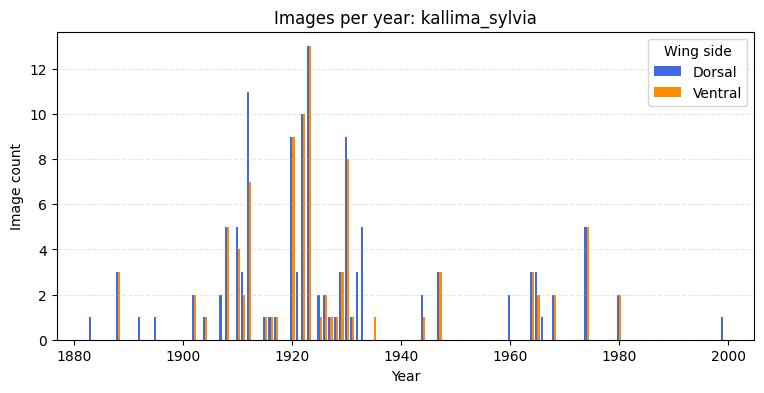

2026-09-21 20:01:29,730 [INFO] Year range: 1883-1999 across 38 distinct years


In [59]:
year_counts = (
    meta.filter(pl.col("year").is_not_null())
    .group_by(["year", "side"])
    .agg(pl.len().alias("count"))
    .sort("year")
)

plt.figure(figsize=(9, 4))
bar_width = 0.4
for i, (side, color) in enumerate(SIDE_COLORS.items()):
    side_counts = year_counts.filter(pl.col("side") == side)
    if side_counts.is_empty():
        continue
    offset = bar_width * (i - 0.5)
    plt.bar(
        side_counts["year"].to_numpy() + offset,
        side_counts["count"].to_numpy(),
        width=bar_width,
        color=color,
        label=side.capitalize(),
    )

plt.title(f"Images per year: {SPECIES_FILTER or 'all species'}")
plt.xlabel("Year")
plt.ylabel("Image count")
plt.legend(title="Wing side")
plt.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.show()

logger.info(
    "Year range: %s-%s across %d distinct years",
    year_counts["year"].min(), year_counts["year"].max(), year_counts["year"].n_unique(),
)

#### Compute species centroids

In [ ]:
def compute_centroids(
    meta: pl.DataFrame,
    embeddings: np.ndarray,
    img_ids: np.ndarray,
    species_filter: str | None = None,
) -> tuple[list[tuple[str, str]], np.ndarray]:
    """Compute normalized centroids for each (species, side) group.

    Returns:
        keys: list of (species, side) tuples
        centroids: (M, 768) normalized float32 array
    """
    if species_filter:
        logger.info(f"Computing centroids for species \"{species_filter}\"")
    else:
        logger.info("Computing centroids for all species with >= %d images", MIN_SPECIES_IMAGES)

    # Build img_id -> index lookup
    id_to_idx = {img_id: i for i, img_id in enumerate(img_ids)}

    # Filter metadata to only species we want
    if species_filter:
        meta = meta.filter(pl.col("species") == species_filter)

    # Group by species + side
    groups = meta.group_by(["species", "side"]).agg(pl.col("img_id"))

    keys = []
    centroid_list = []

    for row in groups.iter_rows(named=True):
        species = row["species"]
        side = row["side"]
        group_img_ids = row["img_id"]

        if side not in SIDES:
            continue

        # Get indices for this group's images
        indices = [id_to_idx[iid] for iid in group_img_ids if iid in id_to_idx]
        if not indices:
            continue

        # Compute centroid (mean of normalized embeddings, then re-normalize)
        centroid = embeddings[indices].mean(axis=0)
        norm = np.linalg.norm(centroid)
        if norm > 0:
            centroid /= norm

        keys.append((species, side))
        centroid_list.append(centroid)

    centroids = np.array(centroid_list, dtype=np.float32)
    
    if len(keys) == 0:
        logger.warning("No species + side groups found. Exiting.")
        duck_conn.close()
        return [], np.array([], dtype=np.float32)

    logger.info(
        f"Computed {len(keys)} centroids. Shape: {centroids.shape}"
    )
    return keys, centroids

keys, centroids = compute_centroids(meta, embeddings, img_ids, SPECIES_FILTER)
#logger.info(f"Keys: {keys}")
#logger.info(f"Centroids: {centroids}")

2026-09-21 20:01:29,736 [INFO] Computing centroids for species "kallima_sylvia"
2026-09-21 20:01:29,739 [INFO] Computed 2 centroids. Shape: (2, 768)
2026-09-21 20:01:29,739 [INFO] Keys: [('kallima_sylvia', 'dorsal'), ('kallima_sylvia', 'ventral')]


#### Compute centroids over time buckets

Grouping dated images into `BUCKET_YEARS`-wide time buckets (default 10 years), labeled by each bucket's start year. Dorsal and ventral are separate, and a given `(side, bucket)` group is dropped if it has fewer than `MIN_BUCKET_IMAGES` images for that side.

In [61]:
def compute_temporal_centroids(
    meta: pl.DataFrame,
    embeddings: np.ndarray,
    img_ids: np.ndarray,
    species_filter: str,
    bucket_years: int = BUCKET_YEARS,
    min_bucket_images: int = MIN_BUCKET_IMAGES,
) -> tuple[list[tuple[str, int]], np.ndarray, dict]:
    """Compute normalized centroids per (side, time bucket) for one species.

    Time buckets are `bucket_years`-wide and labeled by their start year
    (ex: bucket_years=10 groups 1930-1939 under bucket 1930). Dorsal and
    ventral images are kept separate throughout; a (side, bucket) group is
    dropped if it has fewer than `min_bucket_images` images for that side.

    Returns:
        keys: list of (side, bucket_start_year) tuples, sorted by side then bucket
        centroids: (M, 768) normalized float32 array, aligned with keys
        counts: dict mapping (side, bucket_start_year) -> image count
    """
    logger.info(
        "Computing temporal centroids for '%s' (bucket_years=%d, min_bucket_images=%d)",
        species_filter, bucket_years, min_bucket_images,
    )

    id_to_idx = {img_id: i for i, img_id in enumerate(img_ids)}

    species_meta = meta.filter(
        (pl.col("species") == species_filter) & pl.col("year").is_not_null()
    ).with_columns(
        ((pl.col("year") // bucket_years) * bucket_years).alias("bucket")
    )

    groups = species_meta.group_by(["side", "bucket"]).agg(pl.col("img_id")).sort(["side", "bucket"])

    keys = []
    centroid_list = []
    counts = {}

    for row in groups.iter_rows(named=True):
        side = row["side"]
        bucket = row["bucket"]
        group_img_ids = row["img_id"]

        if side not in SIDES:
            continue

        indices = [id_to_idx[iid] for iid in group_img_ids if iid in id_to_idx]
        if len(indices) < min_bucket_images:
            continue

        centroid = embeddings[indices].mean(axis=0)
        norm = np.linalg.norm(centroid)
        if norm > 0:
            centroid /= norm

        key = (side, bucket)
        keys.append(key)
        centroid_list.append(centroid)
        counts[key] = len(indices)

    centroids_arr = np.array(centroid_list, dtype=np.float32)
    logger.info("Computed %d temporal centroids (dropped groups below %d images)", len(keys), min_bucket_images)
    return keys, centroids_arr, counts


temporal_keys, temporal_centroids, temporal_counts = compute_temporal_centroids(
    meta, embeddings, img_ids, SPECIES_FILTER
)
logger.info("Temporal keys (side, bucket_start_year): %s", temporal_keys)

2026-09-21 20:01:29,746 [INFO] Computing temporal centroids for 'kallima_sylvia' (bucket_years=10, min_bucket_images=5)
2026-09-21 20:01:29,751 [INFO] Computed 13 temporal centroids (dropped groups below 5 images)
2026-09-21 20:01:29,751 [INFO] Temporal keys (side, bucket_start_year): [('dorsal', 1900), ('dorsal', 1910), ('dorsal', 1920), ('dorsal', 1930), ('dorsal', 1940), ('dorsal', 1960), ('dorsal', 1970), ('ventral', 1900), ('ventral', 1910), ('ventral', 1920), ('ventral', 1930), ('ventral', 1960), ('ventral', 1970)]


#### Visualize cosine distance over time

Computing two distance metrics for every time bucket centroid:
* `overall` — distance from the bucket centroid to that side's whole-species
  centroid (from the earlier "Compute species centroids" step). Shows how far
  a given period sits from the species' overall average appearance.
* `baseline` — distance from the bucket centroid to that side's *earliest*
  bucket centroid. Shows cumulative drift from the earliest dated period.

`DISTANCE_METRIC` selects which one is plotted; default is `"baseline"`.

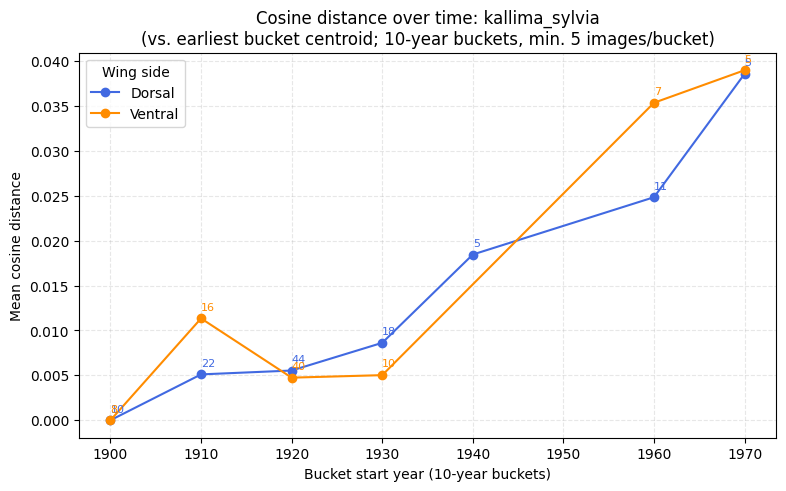

In [62]:
def compute_temporal_distances(
    temporal_keys: list[tuple[str, int]],
    temporal_centroids: np.ndarray,
    temporal_counts: dict,
    overall_keys: list[tuple[str, str]],
    overall_centroids: np.ndarray,
) -> pl.DataFrame:
    """Compute both temporal cosine-distance metrics for each (side, bucket) centroid.

    - "overall": distance from the bucket centroid to that side's whole-species
      centroid (computed once over all available images for that side).
    - "baseline": distance from the bucket centroid to that side's earliest
      bucket centroid (temporal_keys/temporal_centroids must already be sorted
      by side then bucket, as compute_temporal_centroids returns them).
    """
    overall_by_side = {side: centroid for (_, side), centroid in zip(overall_keys, overall_centroids)}

    baseline_by_side = {}
    rows = []
    for (side, bucket), centroid in zip(temporal_keys, temporal_centroids):
        baseline_by_side.setdefault(side, centroid)

        n = temporal_counts[(side, bucket)]
        if side in overall_by_side:
            rows.append({
                "side": side, "bucket": bucket, "n": n, "metric": "overall",
                "distance": 1 - float(np.dot(centroid, overall_by_side[side])),
            })
        rows.append({
            "side": side, "bucket": bucket, "n": n, "metric": "baseline",
            "distance": 1 - float(np.dot(centroid, baseline_by_side[side])),
        })

    return pl.DataFrame(rows)


temporal_distances_df = compute_temporal_distances(
    temporal_keys, temporal_centroids, temporal_counts, keys, centroids
)

DISTANCE_METRIC = "baseline"  # "overall" (vs. whole-species centroid) or "baseline" (vs. earliest bucket)

plot_data = temporal_distances_df.filter(pl.col("metric") == DISTANCE_METRIC).sort("bucket")

plt.figure(figsize=(9, 5))
for side, color in SIDE_COLORS.items():
    side_data = plot_data.filter(pl.col("side") == side)
    if side_data.is_empty():
        continue
    buckets = side_data["bucket"].to_numpy()
    distances = side_data["distance"].to_numpy()
    counts = side_data["n"].to_numpy()
    plt.plot(buckets, distances, color=color, marker="o", label=side.capitalize())
    for x, y, n in zip(buckets, distances, counts):
        plt.annotate(str(n), (x, y), textcoords="offset points", xytext=(0, 6), fontsize=8, color=color)

metric_label = {
    "overall": "whole-species centroid",
    "baseline": "earliest bucket centroid",
}[DISTANCE_METRIC]
plt.title(
    f"Cosine distance over time: {SPECIES_FILTER}\n"
    f"(vs. {metric_label}; {BUCKET_YEARS}-year buckets, min. {MIN_BUCKET_IMAGES} images/bucket)"
)
plt.xlabel(f"Bucket start year ({BUCKET_YEARS}-year buckets)")
plt.ylabel("Mean cosine distance")
plt.legend(title="Wing side")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### Single-species centroid visualization

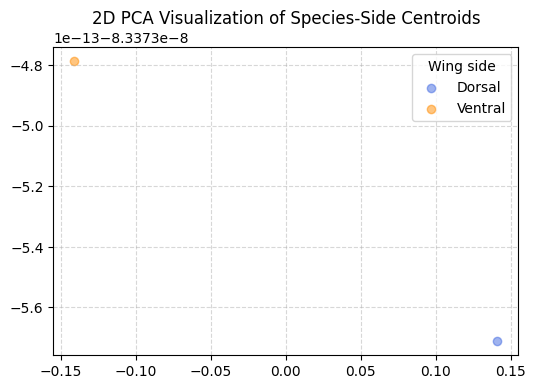

In [63]:
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(centroids)

plt.figure(figsize=(6, 4))
for side, color in SIDE_COLORS.items():
    side_mask = np.array([key[1] == side for key in keys])
    if side_mask.any():
        plt.scatter(
            reduced_vectors[side_mask, 0],
            reduced_vectors[side_mask, 1],
            alpha=0.5,
            color=color,
            label=side.capitalize(),
        )

plt.title("2D PCA Visualization of Species-Side Centroids")
plt.legend(title="Wing side")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### Project steps
* Take centroid (average) and compute distances to each image from there (example: precompute_similarity.py)
* Create visualizations for data analysis over time:
    * Use scikit-learn
    * Graph average centroid distance (distance, y axis) per month (time on x-axis) 
* Test on individual species to preview and modify graph(s) and visualizations; later, batch compute for all eligible (100+ images) species to add to species detail page